# Titanic Dataset

 ### Import Libraries

- Numpy for numerical operations
- Pandas for data handling
- Matplotlib/Seaborn for visualization

In [4]:
pip install numpy pandas matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 517.6 kB/s eta 0:00:00 kB/s eta 0:00:01
  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp312-cp312-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 7.9 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 8.7 MB/s eta 0:00:00m eta 0:00:010:0101m
Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 13.5 MB/s

In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#For better visuals
sns.set(style='whitegrid')

### Load Dataset

In [4]:
df = pd.read_csv('Titanic-Dataset.xls')

In [5]:
print('Shape of the file', df.shape)
df.head()


Shape of the file (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Understanding Dataset

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


- Pclass: Passenger Class (1st, 2nd, or 3rd).
- SibSp: Siblings / Spouses. How many brothers, sisters, or partners were with them.
- Parch: Parents / Children. How many kids or parents were on board.
- Fare: How much they paid for the ticket.
- Embarked: The port where they got on the ship (C = Cherbourg, Q = Queenstown, S = Southampton).
- Ticket: The ticket number (usually a mix of numbers and letters).
- Cabin: The cabin number where the passenger stayed (e.g., C85, B5).

In [22]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


- 12 features, 891 samples = 891 humans. Missing values only in Age
- **Survived from all** - 0.38 percent = 339 person
- **Mean age of passangers** = 30, youngest = 5 month old baby

### Handling Missing Values

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

- Age column has - 177 empty fields
- Cabin columns has - 687
- ...

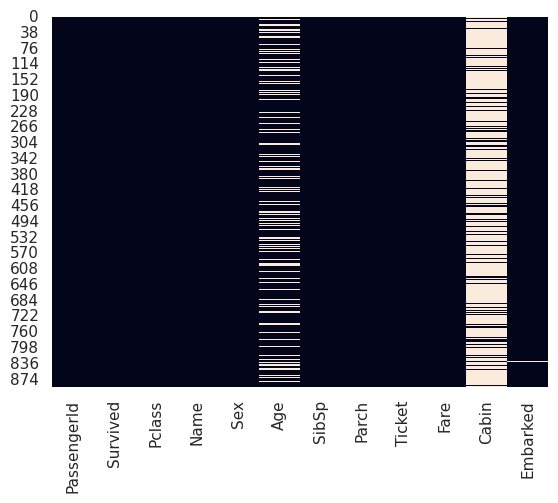

In [7]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

### Univariate Analysis

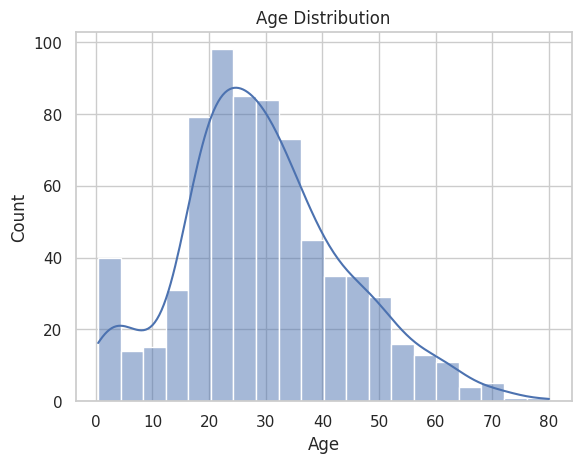

In [8]:
plt.figure()
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

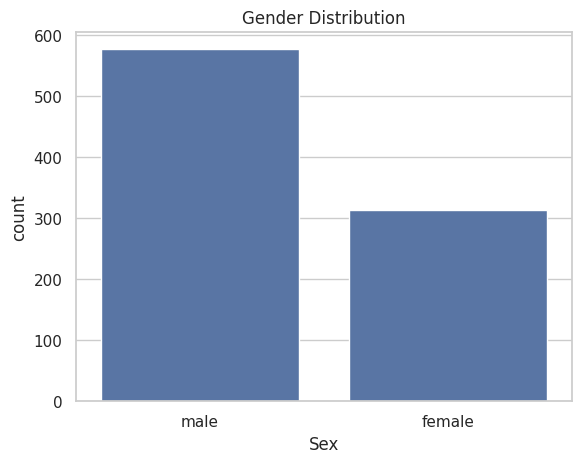

Sex
male      577
female    314
Name: count, dtype: int64

In [25]:
sns.countplot(x='Sex', data=df)
plt.title("Gender Distribution")
plt.show()
display(df['Sex'].value_counts())

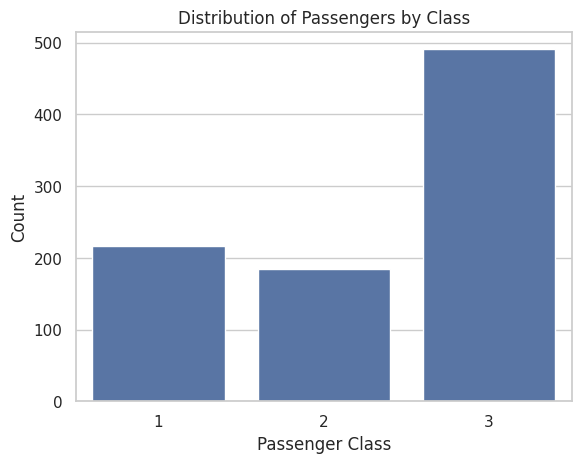

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [16]:
sns.countplot(x='Pclass', data=df)
plt.title("Distribution of Passengers by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()
display(df['Pclass'].value_counts())

### Bivariate Analysis

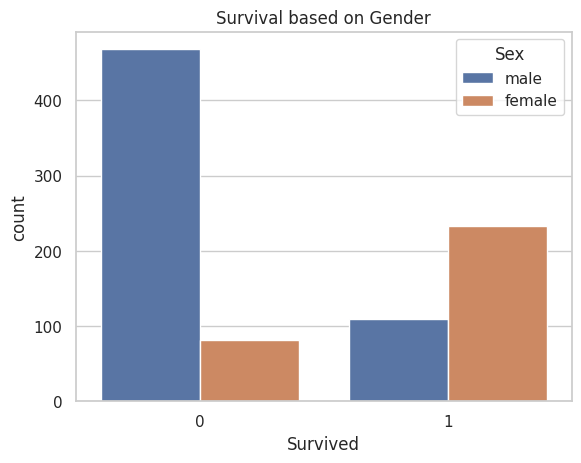

Survived,0,1
Sex,,
female,81,233
male,468,109


In [26]:
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title("Survival based on Gender")
plt.show()
gender_survival = df.groupby('Sex')['Survived'].value_counts().unstack()
gender_survival


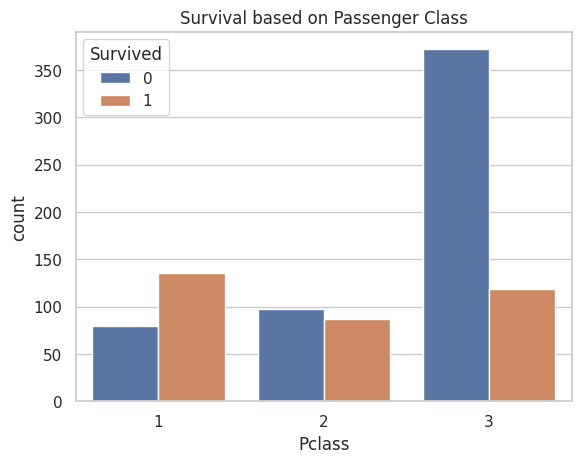

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


In [21]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival based on Passenger Class")
plt.show()
# Survival count by passenger class
class_survival = df.groupby('Pclass')['Survived'].value_counts().unstack()
class_survival

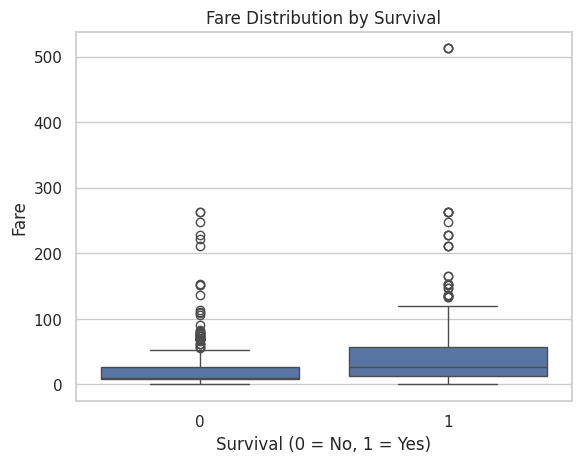

In [33]:
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title("Fare Distribution by Survival")
plt.xlabel("Survival (0 = No, 1 = Yes)")
plt.ylabel("Fare")
plt.show()


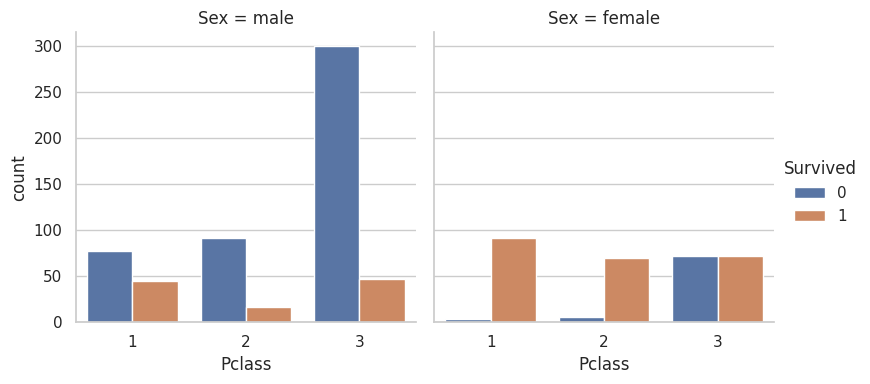

Survived         0   1
Pclass Sex            
1      female    3  91
       male     77  45
2      female    6  70
       male     91  17
3      female   72  72
       male    300  47

In [28]:
sns.catplot(
    x='Pclass',
    hue='Survived',
    col='Sex',
    data=df,
    kind='count',
    height=4,
    aspect=1
)
plt.show()

gender_class_survival = (
    df.groupby(['Pclass', 'Sex'])['Survived']
    .value_counts()
    .unstack()
)
gender_class_survival


### ! Impossible to make prediction based on Age due to a lot of null values. Possible that man who survived was in his mid/old age

### Correlation Analysis

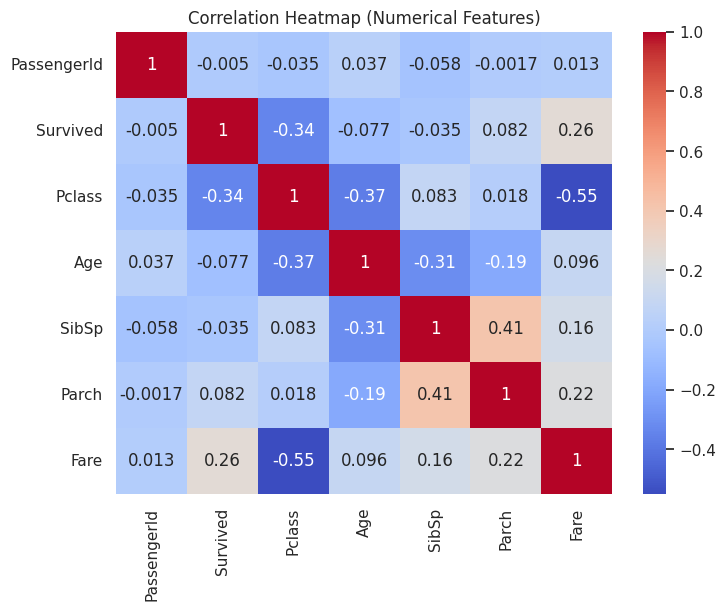

In [29]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()


### Encode

In [30]:
# Encode Sex column
df['Sex_encoded'] = df['Sex'].map({'male': 0, 'female': 1})

# Check encoding
df[['Sex', 'Sex_encoded']].head()


,Sex,Sex_encoded
0,male,0
1,female,1
2,female,1
3,female,1
4,male,0


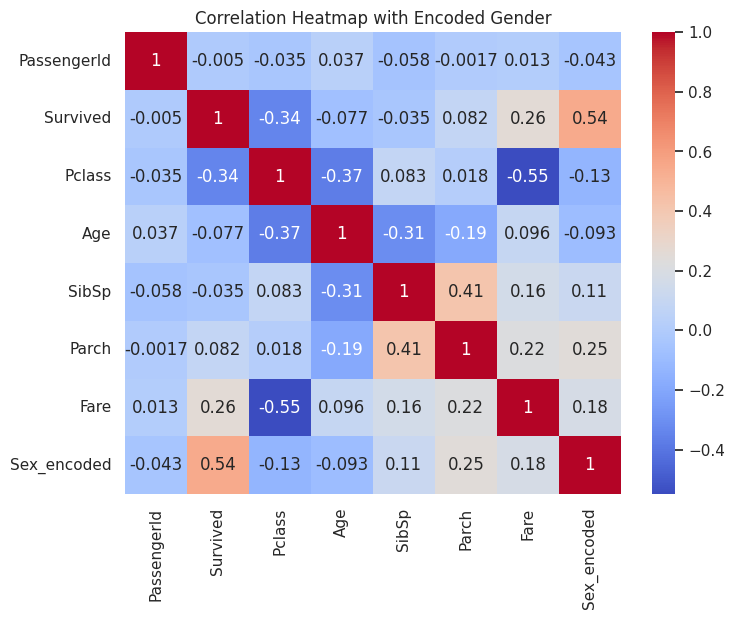

In [31]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap with Encoded Gender")
plt.show()


### Outlier Detection

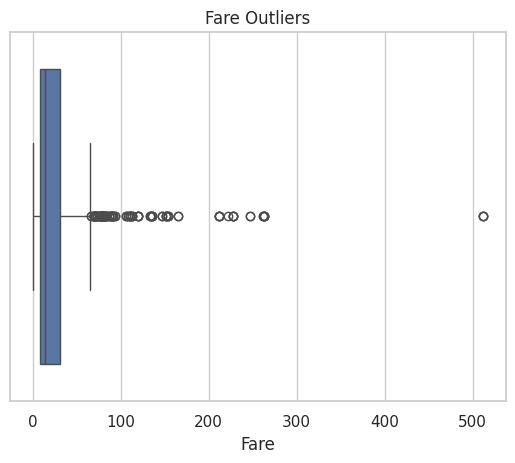

In [13]:
sns.boxplot(x=df['Fare'])
plt.title("Fare Outliers")
plt.show()

### Conclusion

Analysis shows passangers who paid more and who is female had highest chances to survive